# LigandMPNN Results Evaluation _(BindingDB)_
## Part 1: Log Probability Analysis & Tanimoto Similarity

Input: 
    LigandMPNN results (scores/*.pt)
    
Output:
1. LigandMPNN
    1. Log probability distributions (target vs off-target)
    2. Sequence-level statistics
    3. Tanimoto similarity between target and off-target ligands
2. Binding Affinity
    1. Boltz-2 structure prediction (sequence recovery, binding affinity)
    2. GNINA (high accuracy binding affinity prediction)

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
from collections import defaultdict
import json

# RDKit for Tanimoto similarity and ligand atom counts
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit import DataStructs

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

In [33]:
ASSAY_TYPE = "Kd"
# ASSAY_TYPE = "IC50"

# Paths
BASE_DIR = Path(f"/scratch/yunmin/data/graph/lmpnn/bdb_pdb/{ASSAY_TYPE}/lmpnn_out")
CSV_PATH = Path(f"/scratch/yunmin/data/graph/bdb/clustered/bindingdb_{ASSAY_TYPE}_clustered_stage1.csv")
OUTPUT_DIR = Path(f"/scratch/yunmin/data/graph/lmpnn/bdb_pdb/{ASSAY_TYPE}/eval")
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_PLOTS_DIR.mkdir(exist_ok=True)

# Number of designed sequences per target
N_SEQUENCES = 10

## Load BindingDB Data

In [4]:
# Load CSV with ligand information
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} entries from BindingDB")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 96 entries from BindingDB
Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'original_Kd_nM', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'pKd', 'affinity_tier', 'size_category', 'mw', 'logp', 'hbd', 'hba', 'rotatable_bonds', 'aromatic_rings', 'heavy_atoms', 'ligand_size', 'cluster_id']


,protein_key,uniprot_id,target_name,target_source,sequence,sequence_length,ligand_inchikey,ligand_smiles,ligand_name,ligand_het_id,...,size_category,mw,logp,hbd,hba,rotatable_bonds,aromatic_rings,heavy_atoms,ligand_size,cluster_id
0,O60674_Homo sapiens,O60674,Tyrosine-protein kinase JAK2,Homo sapiens,MGMACLTMTEMEGTSTSSIYQNGDISGNANSMKQIDPVLQVYLYHS...,1132,JCINBYQJBYJGDM-UHFFFAOYSA-N,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,BMS-911543,50V,...,very_large,432.532,3.49542,1,8,6,4,32,large,tight_binder (>=8.5)_very_large_large
1,O60674_Homo sapiens,O60674,Tyrosine-protein kinase JAK2,Homo sapiens,MGMACLTMTEMEGTSTSSIYQNGDISGNANSMKQIDPVLQVYLYHS...,1132,JOOXLOJCABQBSG-UHFFFAOYSA-N,Cc1cnc(Nc2ccc(OCCN3CCCC3)cc2)nc1Nc1cccc(c1)S(=...,CHEMBL1287853::N-tert-butyl-3-(5-methyl-2-(4-(...,2TA,...,very_large,524.691,4.82362,3,8,10,3,37,large,tight_binder (>=8.5)_very_large_large
2,O60674_Homo sapiens,O60674,Tyrosine-protein kinase JAK2,Homo sapiens,MGMACLTMTEMEGTSTSSIYQNGDISGNANSMKQIDPVLQVYLYHS...,1132,UJLAWZDWDVHWOW-YPMHNXCESA-N,C[C@@H]1CCN(C[C@@H]1N(C)c1ncnc2[nH]ccc12)C(=O)...,"3-((3R,4R)-4-methyl-3-(methyl(7H-pyrrolo[2,3-d...",MI1,...,very_large,312.377,1.54478,1,5,3,2,23,medium,tight_binder (>=8.5)_very_large_medium
3,O60674_Homo sapiens,O60674,Tyrosine-protein kinase JAK2,Homo sapiens,MGMACLTMTEMEGTSTSSIYQNGDISGNANSMKQIDPVLQVYLYHS...,1132,IBPVXAOOVUAOKJ-UHFFFAOYSA-N,Fc1cc(cc(F)c1CN1CCOCC1)-c1cccc2ncc(nc12)-c1cnn...,"4-(2,6-difluoro-4-(3-(1-(piperidin-4-yl)-1H-py...",DQX,...,very_large,490.558,4.19520,1,7,5,4,36,large,non_binder (≤4.5)_very_large_large
4,O60674_Homo sapiens,O60674,Tyrosine-protein kinase JAK2 [808-1132],Homo sapiens,FRAIIRDLNSLFTPDYELLTENDMLPNMRIGALGFSGAFEDRDPTQ...,335,QQXWNIAQCDPFCH-UHFFFAOYSA-N,Nc1nc(Nc2ccc(cc2)S(N)(=O)=O)nn1C(=O)Nc1ccc(OCC...,"CHEMBL4476380::US12110278, Compound 10",M4G,...,large,447.433,0.79490,5,10,7,3,31,large,non_binder (≤4.5)_large_large


## Helper Functions

In [26]:
def load_lmpnn_scores(pt_path: Path) -> Dict:
    """
    Load LigandMPNN score .pt file
    Expected keys: 'log_probs', 'logits', 'S', 'decoding_order'
    """
    data = torch.load(pt_path, map_location='cpu')
    return data


def extract_log_probs(score_data: Dict) -> np.ndarray:
    """
    Extract log probabilities from score dictionary
    Returns: [num_sequences, seq_length] array
    
    For score.py output:
    - log_probs: [L, 21] - log probabilities for each position and AA
    - native_sequence: [L] - the native sequence indices
    - mask: [L] - mask for valid positions
    """
    log_probs = score_data['log_probs']  # Should be [L, 21]
    native_sequence = score_data['native_sequence']  # [L]
    mask = score_data.get('mask', None)
    
    if isinstance(log_probs, torch.Tensor):
        log_probs = log_probs.cpu().numpy()
    if isinstance(native_sequence, torch.Tensor):
        native_sequence = native_sequence.cpu().numpy()
    if mask is not None and isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    
    # Sequence length
    if len(log_probs.shape) == 2:
        L = log_probs.shape[0]
    elif len(log_probs.shape) == 3:
        L = log_probs.shape[1]
    else:
        raise ValueError(f"Unexpected log_probs shape: {log_probs.shape}")
    
    # Extract log prob of native amino acid at each position
    # if single sequence ([L, 21]), convert to [1, L]
    if len(log_probs.shape) == 2:
        selected_log_probs = np.zeros(L)
        for l in range(L):
            if mask is None or mask[l] > 0:
                aa_idx = int(native_sequence[l])
                selected_log_probs[l] = log_probs[l, aa_idx]
            else:
                selected_log_probs[l] = np.nan 
        return selected_log_probs.reshape(1, -1)  # [1, L]
    
    else:
        # Batched sequences: [B, L, 21]
        B = log_probs.shape[0]
        selected_log_probs = np.zeros((B, L))
        
        for b in range(B):
            for l in range(L):
                if mask is None or mask[l] > 0:
                    aa_idx = int(native_sequence[l])
                    selected_log_probs[b, l] = log_probs[b, l, aa_idx]
                else:
                    selected_log_probs[b, l] = np.nan
        
        return selected_log_probs


def compute_sequence_metrics(log_probs: np.ndarray) -> Dict:
    """
    Compute metrics from log probabilities
    """
    return {
        'mean_log_p': np.mean(log_probs),
        'std_log_p': np.std(log_probs),
        'median_log_p': np.median(log_probs),
        'min_log_p': np.min(log_probs),
        'perplexity': np.exp(-np.mean(log_probs)),
        'mean_confidence': np.exp(np.mean(log_probs)),  # probability scale
        'position_entropy': -np.sum(np.exp(log_probs) * log_probs, axis=0).mean()
    }

def calculate_tanimoto_similarity(smiles1: str, smiles2: str, radius: int = 2) -> float:
    """
    Calculate Tanimoto similarity between two molecules
    
    Args:
        smiles1, smiles2: SMILES strings
        radius: Morgan fingerprint radius (default=2)
    
    Returns:
        Tanimoto similarity score [0, 1]
    """
    try:
        mol1 = Chem.MolFromSmiles(smiles1)
        mol2 = Chem.MolFromSmiles(smiles2)
        
        if mol1 is None or mol2 is None:
            return np.nan
        
        from rdkit.Chem import rdFingerprintGenerator
        mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius)
        fp1 = mfpgen.GetFingerprint(mol1)
        fp2 = mfpgen.GetFingerprint(mol2)
        
        return DataStructs.TanimotoSimilarity(fp1, fp2)
    except:
        return np.nan

## Scan and Load All Results

In [23]:
def scan_lmpnn_results(base_dir: Path) -> Dict:
    """
    Scan directory structure and collect all score files
    Returns: {uniprot_id: {target/off-target: {lig_id: pt_path}}}
    """
    results = defaultdict(lambda: {'tar': {}, 'off': {}})
    
    for protein_dir in base_dir.iterdir():
        if not protein_dir.is_dir():
            continue
        
        uniprot_id = protein_dir.name
        
        for tar_off in ['tar', 'off']:
            tar_off_dir = protein_dir / tar_off
            if not tar_off_dir.exists():
                continue
            
            for lig_dir in tar_off_dir.iterdir():
                if not lig_dir.is_dir():
                    continue
                
                lig_id = lig_dir.name
                scores_dir = lig_dir / 'scores'
                
                if scores_dir.exists():
                    # Find .pt files
                    pt_files = list(scores_dir.glob('*_1.pt'))
                    if pt_files:
                        results[uniprot_id][tar_off][lig_id] = pt_files[0]
    
    return dict(results)


print("Scanning LigandMPNN output directory...")
all_results = scan_lmpnn_results(BASE_DIR)
print(f"Found {len(all_results)} proteins with results")

# Summary statistics
n_targets = sum(len(v['tar']) for v in all_results.values())
n_offtargets = sum(len(v['off']) for v in all_results.values())
print(f"Total target designs: {n_targets}")
print(f"Total off-target designs: {n_offtargets}")

Scanning LigandMPNN output directory...
Found 16 proteins with results
Total target designs: 44
Total off-target designs: 45


## Process All Results

In [24]:
def process_all_results(results_dict: Dict, df: pd.DataFrame) -> pd.DataFrame:
    """
    Process all LigandMPNN results and compute metrics
    """
    records = []
    
    for uniprot_id, data in results_dict.items():
        # Process targets
        for lig_id, pt_path in data['tar'].items():
            try:
                score_data = load_lmpnn_scores(pt_path)
                log_probs = extract_log_probs(score_data)
                metrics = compute_sequence_metrics(log_probs)
                
                # Get ligand SMILES from dataframe
                ligand_row = df[(df['uniprot_id'] == uniprot_id) & 
                               (df['ligand_het_id'] == lig_id)]
                smiles = ligand_row['ligand_smiles'].values[0] if len(ligand_row) > 0 else None

                records.append({
                    'uniprot_id': uniprot_id,
                    'ligand_het_id': lig_id,
                    'type': 'target',
                    'ligand_smiles': smiles,
                    'pt_path': str(pt_path),
                    **metrics,
                    'seq_length': log_probs.shape[1],
                    'n_sequences': log_probs.shape[0]
                })
            except Exception as e:
                print(f"Error processing {uniprot_id}/tar/{lig_id}: {e}")
        
        # Process off-targets
        for lig_id, pt_path in data['off'].items():
            try:
                score_data = load_lmpnn_scores(pt_path)
                log_probs = extract_log_probs(score_data)
                metrics = compute_sequence_metrics(log_probs)
                
                ligand_row = df[(df['uniprot_id'] == uniprot_id) & 
                               (df['ligand_het_id'] == lig_id)]
                smiles = ligand_row['ligand_smiles'].values[0] if len(ligand_row) > 0 else None
                
                records.append({
                    'uniprot_id': uniprot_id,
                    'ligand_het_id': lig_id,
                    'type': 'off-target',
                    'ligand_smiles': smiles,
                    'pt_path': str(pt_path),
                    **metrics,
                    'seq_length': log_probs.shape[1],
                    'n_sequences': log_probs.shape[0]
                })
            except Exception as e:
                print(f"Error processing {uniprot_id}/off/{lig_id}: {e}")
    
    return pd.DataFrame(records)


print("Processing all results...")
results_df = process_all_results(all_results, df)
print(f"Processed {len(results_df)} designs")
results_df.head(10)

Processing all results...
Processed 89 designs


,uniprot_id,ligand_het_id,type,ligand_smiles,pt_path,mean_log_p,std_log_p,median_log_p,min_log_p,perplexity,mean_confidence,position_entropy,seq_length,n_sequences
0,O60674,50V,target,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.956753,0.742103,-0.818525,-3.068084,2.603230,0.384138,2.611364,577,10
1,O60674,MI1,target,C[C@@H]1CCN(C[C@@H]1N(C)c1ncnc2[nH]ccc12)C(=O)...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-1.073357,0.756011,-1.053638,-3.227810,2.925183,0.341859,2.706926,575,10
2,O60674,2TA,target,Cc1cnc(Nc2ccc(OCCN3CCCC3)cc2)nc1Nc1cccc(c1)S(=...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-1.035804,0.751904,-0.977484,-3.379006,2.817371,0.354941,2.673465,581,10
3,O60674,8MY,off-target,Nc1cc(nc(Nc2ccc(cc2)C#N)n1)-n1ccc(CO)n1,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.915714,0.739645,-0.758664,-3.911172,2.498557,0.400231,2.582891,272,10
4,O60674,DQX,off-target,Fc1cc(cc(F)c1CN1CCOCC1)-c1cccc2ncc(nc12)-c1cnn...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.995072,0.787370,-0.831892,-3.768666,2.704919,0.369697,2.610464,293,10
5,O60674,M4G,off-target,Nc1nc(Nc2ccc(cc2)S(N)(=O)=O)nn1C(=O)Nc1ccc(OCC...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.871930,0.708280,-0.654231,-3.058487,2.391521,0.418144,2.564755,272,10
6,O60885,8FV,target,COc1cc2c(cc1-c1c(C)noc1C)[nH]c1nc(C)nc(-c3ccnc...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-1.012262,0.659020,-1.024937,-2.380901,2.751818,0.363396,2.792386,113,10
7,O60885,WSH,target,Cc1nnc2[C@H](NC(=O)OCc3ccccc3)N=C(c3ccccc3)c3c...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.863162,0.712106,-0.641867,-2.594188,2.370645,0.421826,2.518650,127,10
8,O60885,ZHV,target,CN(C)CCN1CCC(CC1)n1nnc(C)c1-c1cccc(Oc2cc(Br)cc...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.907703,0.765554,-0.701210,-3.204331,2.478622,0.403450,2.524378,126,10
9,O60885,5U6,off-target,COc1cc(c(OC)cc1CN(C)C)-c1cn(C)c(=O)c2cnccc12,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.958735,0.757963,-0.800710,-3.666381,2.608394,0.383378,2.628592,123,10


## Calculate Tanimoto Similarities

In [27]:
def compute_tanimoto_matrix(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Tanimoto similarity between all target-offtarget pairs per protein
    """
    tanimoto_records = []
    
    for uniprot_id in results_df['uniprot_id'].unique():
        protein_data = results_df[results_df['uniprot_id'] == uniprot_id]
        
        targets = protein_data[protein_data['type'] == 'target']
        offtargets = protein_data[protein_data['type'] == 'off-target']
        
        for _, tar_row in targets.iterrows():
            tar_smiles = tar_row['ligand_smiles']
            if pd.isna(tar_smiles):
                continue
            
            for _, off_row in offtargets.iterrows():
                off_smiles = off_row['ligand_smiles']
                if pd.isna(off_smiles):
                    continue
                
                tanimoto = calculate_tanimoto_similarity(tar_smiles, off_smiles)
                
                tanimoto_records.append({
                    'uniprot_id': uniprot_id,
                    'target_lig_id': tar_row['ligand_het_id'],
                    'offtarget_lig_id': off_row['ligand_het_id'],
                    'target_smiles': tar_smiles,
                    'offtarget_smiles': off_smiles,
                    'tanimoto_similarity': tanimoto
                })
    
    return pd.DataFrame(tanimoto_records)


print("Computing Tanimoto similarities...")
tanimoto_df = compute_tanimoto_matrix(results_df)
print(f"Computed {len(tanimoto_df)} target-offtarget pairs")

# Summary statistics
print(f"\nTanimoto Similarity Statistics:")
print(f"Mean: {tanimoto_df['tanimoto_similarity'].mean():.3f}")
print(f"Median: {tanimoto_df['tanimoto_similarity'].median():.3f}")
print(f"Std: {tanimoto_df['tanimoto_similarity'].std():.3f}")

tanimoto_df.head()

Computing Tanimoto similarities...
Computed 125 target-offtarget pairs

Tanimoto Similarity Statistics:
Mean: 0.128
Median: 0.123
Std: 0.059


,uniprot_id,target_lig_id,offtarget_lig_id,target_smiles,offtarget_smiles,tanimoto_similarity
0,O60674,50V,8MY,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,Nc1cc(nc(Nc2ccc(cc2)C#N)n1)-n1ccc(CO)n1,0.129032
1,O60674,50V,DQX,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,Fc1cc(cc(F)c1CN1CCOCC1)-c1cccc2ncc(nc12)-c1cnn...,0.128440
2,O60674,50V,M4G,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,Nc1nc(Nc2ccc(cc2)S(N)(=O)=O)nn1C(=O)Nc1ccc(OCC...,0.144330
3,O60674,MI1,8MY,C[C@@H]1CCN(C[C@@H]1N(C)c1ncnc2[nH]ccc12)C(=O)...,Nc1cc(nc(Nc2ccc(cc2)C#N)n1)-n1ccc(CO)n1,0.149425
4,O60674,MI1,DQX,C[C@@H]1CCN(C[C@@H]1N(C)c1ncnc2[nH]ccc12)C(=O)...,Fc1cc(cc(F)c1CN1CCOCC1)-c1cccc2ncc(nc12)-c1cnn...,0.134615


## Compute Delta Log P (Target - Off-target)

In [28]:
def compute_delta_metrics(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Δlog p and other delta metrics between target and off-target
    """
    delta_records = []
    
    for uniprot_id in results_df['uniprot_id'].unique():
        protein_data = results_df[results_df['uniprot_id'] == uniprot_id]
        
        targets = protein_data[protein_data['type'] == 'target']
        offtargets = protein_data[protein_data['type'] == 'off-target']
        
        if len(targets) == 0 or len(offtargets) == 0:
            continue
        
        # Average across all target-offtarget combinations
        for _, tar_row in targets.iterrows():
            for _, off_row in offtargets.iterrows():
                delta_records.append({
                    'uniprot_id': uniprot_id,
                    'target_lig_id': tar_row['ligand_het_id'],
                    'offtarget_lig_id': off_row['ligand_het_id'],
                    'delta_mean_log_p': tar_row['mean_log_p'] - off_row['mean_log_p'],
                    'delta_perplexity': tar_row['perplexity'] - off_row['perplexity'],
                    'delta_confidence': tar_row['mean_confidence'] - off_row['mean_confidence'],
                    'target_mean_log_p': tar_row['mean_log_p'],
                    'offtarget_mean_log_p': off_row['mean_log_p'],
                    'target_perplexity': tar_row['perplexity'],
                    'offtarget_perplexity': off_row['perplexity']
                })
    
    return pd.DataFrame(delta_records)


print("Computing delta metrics...")
delta_df = compute_delta_metrics(results_df)
print(f"Computed {len(delta_df)} delta comparisons")

print(f"\nΔlog p Statistics:")
print(f"Mean: {delta_df['delta_mean_log_p'].mean():.4f}")
print(f"Median: {delta_df['delta_mean_log_p'].median():.4f}")
print(f"Positive Δlog p (target better): {(delta_df['delta_mean_log_p'] > 0).sum()} / {len(delta_df)}")

delta_df.head()

Computing delta metrics...
Computed 125 delta comparisons

Δlog p Statistics:
Mean: -0.0140
Median: -0.0178
Positive Δlog p (target better): 50 / 125


,uniprot_id,target_lig_id,offtarget_lig_id,delta_mean_log_p,delta_perplexity,delta_confidence,target_mean_log_p,offtarget_mean_log_p,target_perplexity,offtarget_perplexity
0,O60674,50V,8MY,-0.041039,0.104672,-0.016093,-0.956753,-0.915714,2.603230,2.498557
1,O60674,50V,DQX,0.038319,-0.101689,0.014441,-0.956753,-0.995072,2.603230,2.704919
2,O60674,50V,M4G,-0.084823,0.211709,-0.034006,-0.956753,-0.871930,2.603230,2.391521
3,O60674,MI1,8MY,-0.157643,0.426625,-0.058372,-1.073357,-0.915714,2.925183,2.498557
4,O60674,MI1,DQX,-0.078285,0.220264,-0.027838,-1.073357,-0.995072,2.925183,2.704919


## Visualization: Log P Distributions

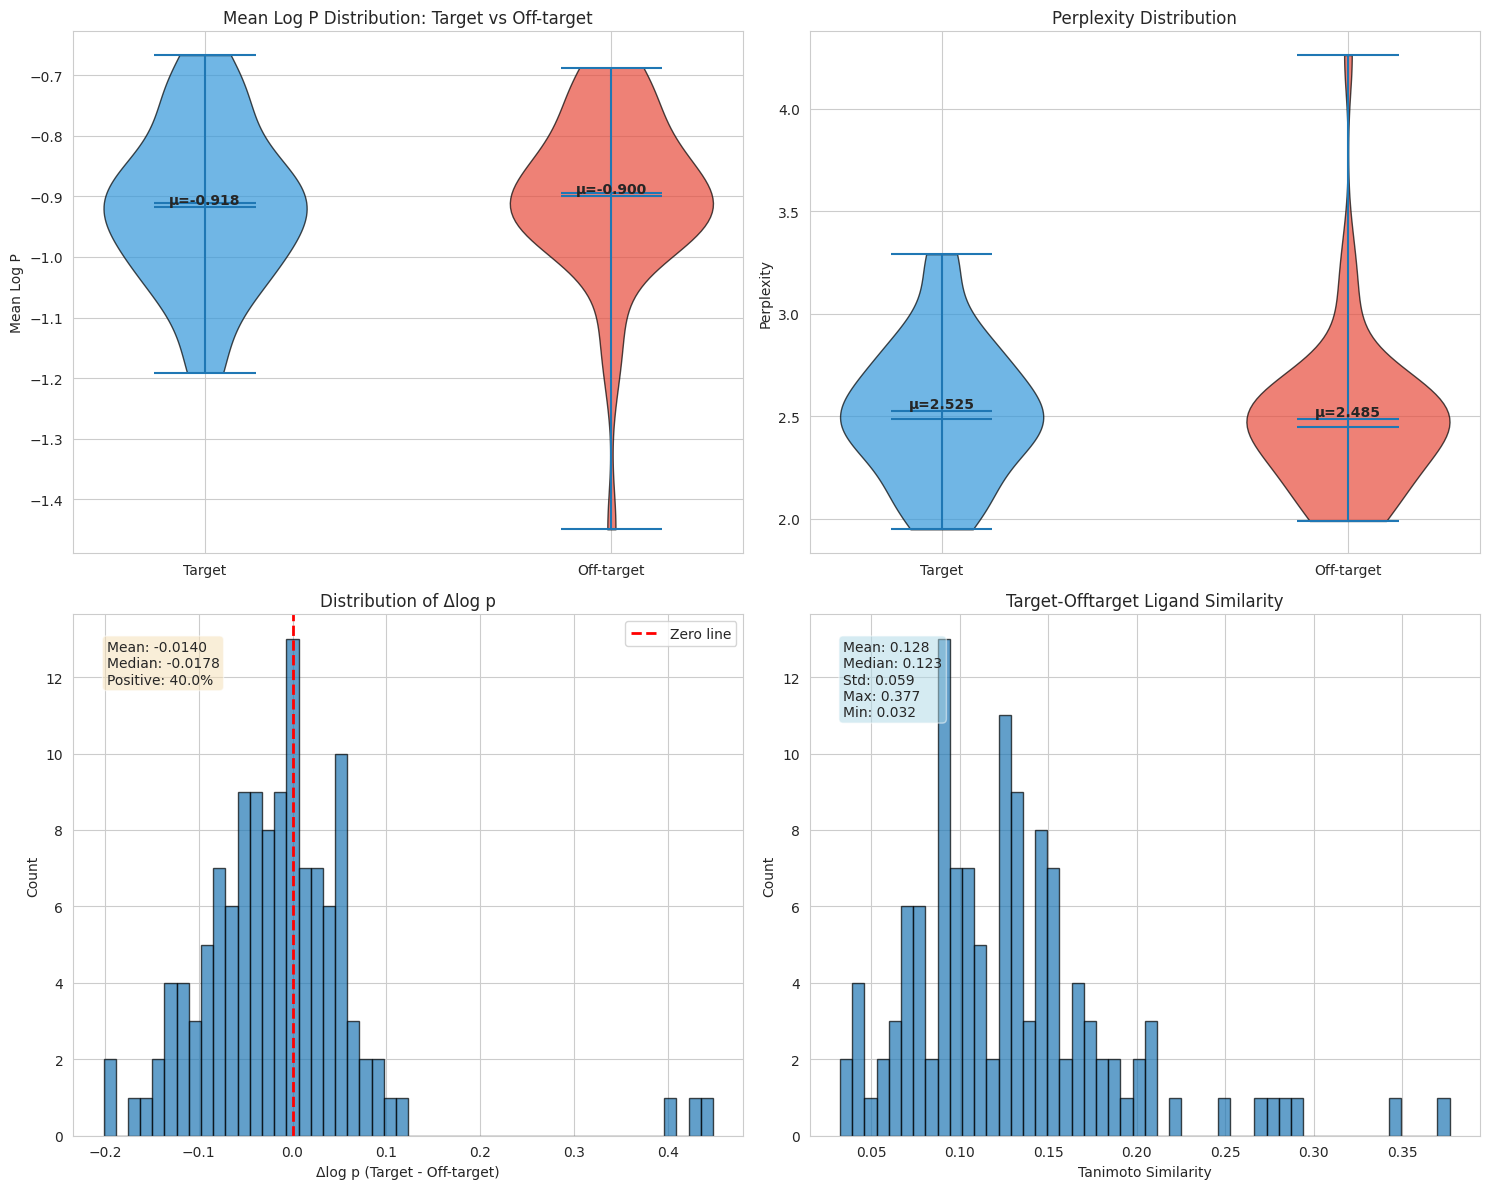

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Color palette
target_color = '#3498db'  # Blue
offtarget_color = '#e74c3c'  # Red

# 1. Log p distribution comparison with colors
violin_parts = axes[0, 0].violinplot(
    [results_df[results_df['type'] == 'target']['mean_log_p'].dropna(),
     results_df[results_df['type'] == 'off-target']['mean_log_p'].dropna()],
    positions=[0, 1],
    showmeans=True,
    showmedians=True
)
for i, (pc, color) in enumerate(zip(violin_parts['bodies'], [target_color, offtarget_color])):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Target', 'Off-target'])
axes[0, 0].set_ylabel('Mean Log P')
axes[0, 0].set_title('Mean Log P Distribution: Target vs Off-target')

# Add mean value labels
target_mean = results_df[results_df['type'] == 'target']['mean_log_p'].mean()
off_mean = results_df[results_df['type'] == 'off-target']['mean_log_p'].mean()
axes[0, 0].text(0, target_mean, f'μ={target_mean:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0, 0].text(1, off_mean, f'μ={off_mean:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Perplexity comparison with colors
violin_parts2 = axes[0, 1].violinplot(
    [results_df[results_df['type'] == 'target']['perplexity'].dropna(),
     results_df[results_df['type'] == 'off-target']['perplexity'].dropna()],
    positions=[0, 1],
    showmeans=True,
    showmedians=True
)
for i, (pc, color) in enumerate(zip(violin_parts2['bodies'], [target_color, offtarget_color])):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Target', 'Off-target'])
axes[0, 1].set_ylabel('Perplexity')
axes[0, 1].set_title('Perplexity Distribution')

# Add mean value labels
target_perp = results_df[results_df['type'] == 'target']['perplexity'].mean()
off_perp = results_df[results_df['type'] == 'off-target']['perplexity'].mean()
axes[0, 1].text(0, target_perp, f'μ={target_perp:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0, 1].text(1, off_perp, f'μ={off_perp:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')


# 3. Delta log p histogram
n, bins, patches = axes[1, 0].hist(delta_df['delta_mean_log_p'], bins=50, 
                                     edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero line')
axes[1, 0].set_xlabel('Δlog p (Target - Off-target)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Distribution of Δlog p')

delta_mean = delta_df['delta_mean_log_p'].mean()
delta_median = delta_df['delta_mean_log_p'].median()
positive_pct = (delta_df['delta_mean_log_p'] > 0).sum() / len(delta_df) * 100

stats_text = f'Mean: {delta_mean:.4f}\nMedian: {delta_median:.4f}\nPositive: {positive_pct:.1f}%'
axes[1, 0].text(0.05, 0.95, stats_text, transform=axes[1, 0].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 0].legend()

# 4. Tanimoto similarity histogram
n2, bins2, patches2 = axes[1, 1].hist(tanimoto_df['tanimoto_similarity'].dropna(), 
                                        bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Tanimoto Similarity')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Target-Offtarget Ligand Similarity')

tani_mean = tanimoto_df['tanimoto_similarity'].mean()
tani_median = tanimoto_df['tanimoto_similarity'].median()
tani_std = tanimoto_df['tanimoto_similarity'].std()
tani_max = tanimoto_df['tanimoto_similarity'].max()
tani_min = tanimoto_df['tanimoto_similarity'].min()

tani_text = f'Mean: {tani_mean:.3f}\nMedian: {tani_median:.3f}\nStd: {tani_std:.3f}\nMax: {tani_max:.3f}\nMin: {tani_min:.3f}'
axes[1, 1].text(0.05, 0.95, tani_text, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_log_p_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Correlation Analysis

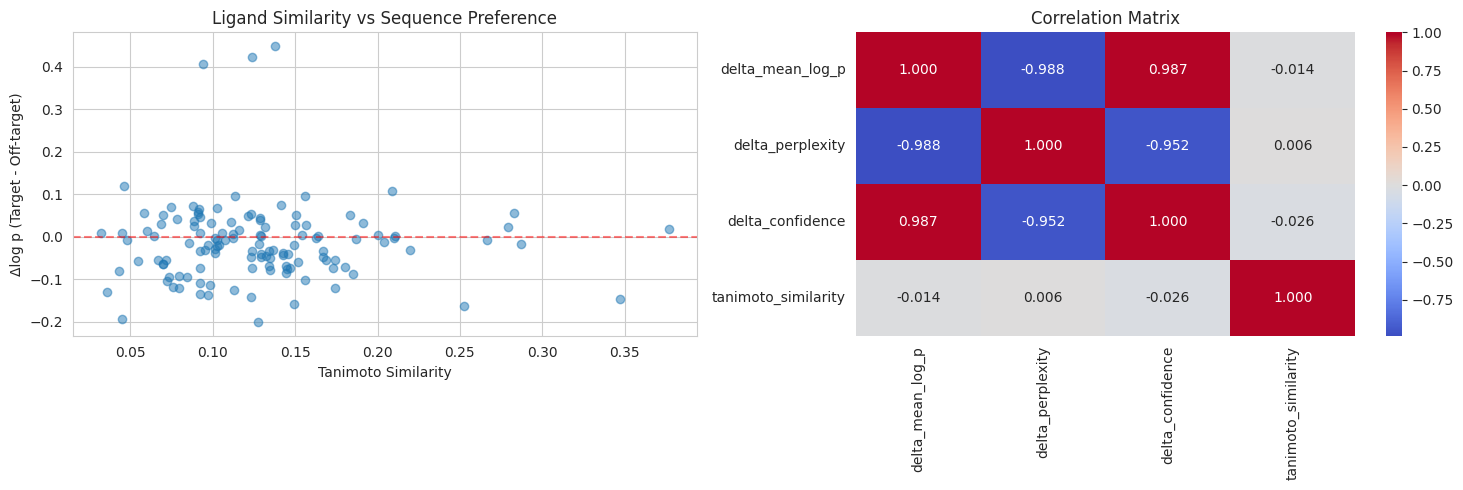

Correlation between Tanimoto similarity and Δlog p:
-0.014


In [42]:
# Merge delta_df with tanimoto_df
merged_df = delta_df.merge(
    tanimoto_df[['uniprot_id', 'target_lig_id', 'offtarget_lig_id', 'tanimoto_similarity']],
    on=['uniprot_id', 'target_lig_id', 'offtarget_lig_id'],
    how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: Tanimoto vs Delta log p
axes[0].scatter(merged_df['tanimoto_similarity'], merged_df['delta_mean_log_p'], alpha=0.5)
axes[0].set_xlabel('Tanimoto Similarity')
axes[0].set_ylabel('Δlog p (Target - Off-target)')
axes[0].set_title('Ligand Similarity vs Sequence Preference')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Correlation heatmap
corr_cols = ['delta_mean_log_p', 'delta_perplexity', 'delta_confidence', 'tanimoto_similarity']
corr_matrix = merged_df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation between Tanimoto similarity and Δlog p:")
print(f"{merged_df[['tanimoto_similarity', 'delta_mean_log_p']].corr().iloc[0, 1]:.3f}")

## Per-Protein Analysis

In [43]:
# Average metrics per protein
per_protein_stats = merged_df.groupby('uniprot_id').agg({
    'delta_mean_log_p': ['mean', 'std', 'min', 'max'],
    'tanimoto_similarity': ['mean', 'std'],
    'target_mean_log_p': 'mean',
    'offtarget_mean_log_p': 'mean'
}).round(4)

per_protein_stats.columns = ['_'.join(col).strip() for col in per_protein_stats.columns]
per_protein_stats = per_protein_stats.sort_values('delta_mean_log_p_mean', ascending=False)

print("Top 10 proteins with highest Δlog p (best specificity):")
print(per_protein_stats.head(10))

print("\nBottom 10 proteins with lowest Δlog p (worst specificity):")
print(per_protein_stats.tail(10))

Top 10 proteins with highest Δlog p (best specificity):
            delta_mean_log_p_mean  delta_mean_log_p_std  delta_mean_log_p_min  \
uniprot_id                                                                      
Q92793                     0.1110                0.2374               -0.0868   
P68400                     0.0417                0.0325               -0.0018   
P62937                     0.0300                0.0229               -0.0084   
P01375                     0.0179                0.0495               -0.0681   
O60885                     0.0102                0.0722               -0.0952   
P07900                     0.0041                0.0276               -0.0324   
P36639                     0.0016                0.0451               -0.0740   
Q13451                    -0.0255                0.1120               -0.1932   
P61964                    -0.0306                0.0180               -0.0554   
P24941                    -0.0313                0.04

## Save Results

In [44]:
# Save all dataframes
HEADER=f'bindingdb_{ASSAY_TYPE}'
results_df.to_csv(OUTPUT_DIR / f'{HEADER}_all_lmpnn_metrics.csv', index=False)
delta_df.to_csv(OUTPUT_DIR / f'{HEADER}_delta_metrics.csv', index=False)
tanimoto_df.to_csv(OUTPUT_DIR / f'{HEADER}_tanimoto_similarities.csv', index=False)
merged_df.to_csv(OUTPUT_DIR / f'{HEADER}_merged_analysis.csv', index=False)
per_protein_stats.to_csv(OUTPUT_DIR / f'{HEADER}_per_protein_statistics.csv', index=False)

print(f"All results saved to {OUTPUT_DIR}")

All results saved to /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/eval


## Summary Report

In [46]:
summary = f"""
=== LigandMPNN Evaluation Summary ===

Total Proteins: {len(results_df['uniprot_id'].unique())}
Total Target Designs: {len(results_df[results_df['type'] == 'target'])}
Total Off-target Designs: {len(results_df[results_df['type'] == 'off-target'])}

Mean Log P:
  Target: {results_df[results_df['type'] == 'target']['mean_log_p'].mean():.4f}
  Off-target: {results_df[results_df['type'] == 'off-target']['mean_log_p'].mean():.4f}
  Δlog p: {delta_df['delta_mean_log_p'].mean():.4f} ± {delta_df['delta_mean_log_p'].std():.4f}

Perplexity:
  Target: {results_df[results_df['type'] == 'target']['perplexity'].mean():.4f}
  Off-target: {results_df[results_df['type'] == 'off-target']['perplexity'].mean():.4f}

Tanimoto Similarity (Target-Off-target Ligands):
  Mean: {tanimoto_df['tanimoto_similarity'].mean():.3f}
  Median: {tanimoto_df['tanimoto_similarity'].median():.3f}
  Range: [{tanimoto_df['tanimoto_similarity'].min():.3f}, {tanimoto_df['tanimoto_similarity'].max():.3f}]

Specificity:
  Proteins with positive Δlog p: {(per_protein_stats['delta_mean_log_p_mean'] > 0).sum()} / {len(per_protein_stats)}
  Best Δlog p: {per_protein_stats['delta_mean_log_p_mean'].max():.4f}
  Worst Δlog p: {per_protein_stats['delta_mean_log_p_mean'].min():.4f}
"""

print(summary)

with open(OUTPUT_DIR / f'{HEADER}_summary_report.txt', 'w') as f:
    f.write(summary)


=== LigandMPNN Evaluation Summary ===

Total Proteins: 16
Total Target Designs: 44
Total Off-target Designs: 45

Mean Log P:
  Target: -0.9180
  Off-target: -0.9000
  Δlog p: -0.0140 ± 0.0947

Perplexity:
  Target: 2.5248
  Off-target: 2.4845

Tanimoto Similarity (Target-Off-target Ligands):
  Mean: 0.128
  Median: 0.123
  Range: [0.032, 0.377]

Specificity:
  Proteins with positive Δlog p: 7 / 16
  Best Δlog p: 0.1110
  Worst Δlog p: -0.1241



---
## Next Steps: Boltz-2 + GNINA Workflow

### Workflow Overview:
```bash
1. Extract designed sequences from LigandMPNN output
2. Run Boltz-2 for structure prediction:
   boltz predict input.yaml --out_dir ./predictions
3. Extract protein-ligand complexes from Boltz-2 output
4. Run GNINA scoring:
   gnina --score_only -r protein.pdb -l ligand.sdf -o scored.sdf
5. Compare binding affinities and sequence recovery rates
```

### Required Next Notebook:
- **boltz2_gnina_evaluation.ipynb**: 
  - Prepare Boltz-2 input files
  - Parse Boltz-2 outputs (pLDDT, PAE)
  - Run GNINA and parse CNNscore/CNNaffinity
  - Calculate sequence recovery rates
  - Compare binding affinity predictions

```

### Check # of Atoms in Ligand

LIGAND ATOM COUNT ANALYSIS

Valid SMILES: 89 / 89

ATOM COUNT STATISTICS
Mean: 26.1 atoms
Median: 25 atoms
Range: 6-78 atoms
Std: 12.1 atoms

⚠️  LIGANDS EXCEEDING BOLTZ-2 LIMIT (>56 atoms)
Count: 2 / 89 (2.2%)

Top violators:
   uniprot_id ligand_het_id  n_heavy_atoms    type
40     P62937           SFA             78  target
51     Q13451           RAP             65  target

By target type:
type
target    2
Name: count, dtype: int64


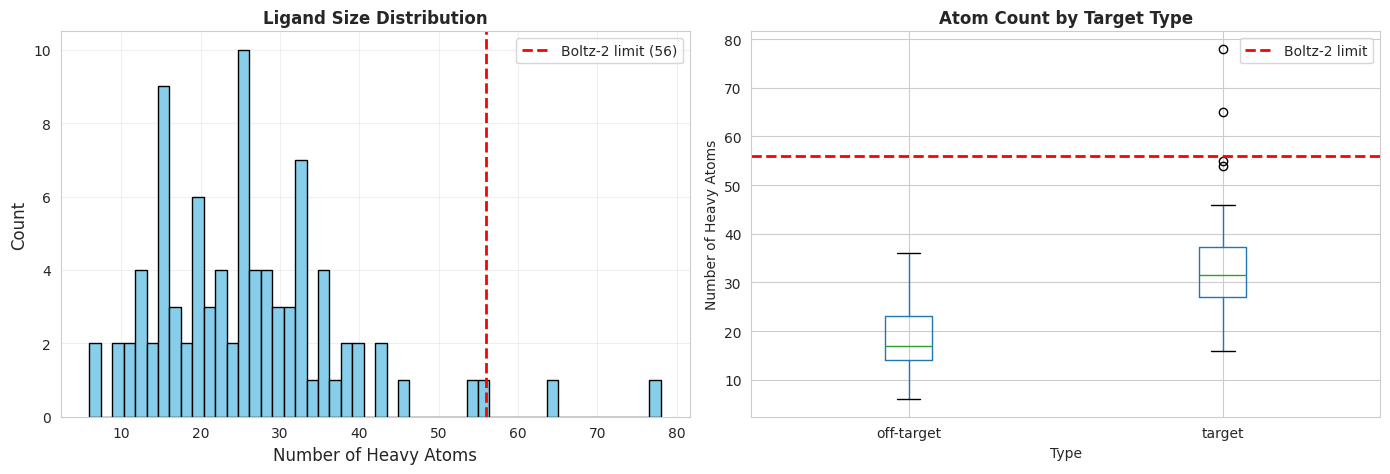


✅ Saved plot to /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/eval/plots/bindingdb_Kd_ligand_atom_counts.png

RECOMMENDATION
Consider excluding 2 ligands (>56 atoms) before Boltz-2 run
These predictions will be unreliable according to Boltz-2 docs

Filtered dataset: 87 / 89 entries


In [48]:
def count_heavy_atoms(smiles: str) -> int:
    """Count heavy (non-hydrogen) atoms in molecule."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return -1
        return mol.GetNumHeavyAtoms()
    except:
        return -1

print("="*60)
print("LIGAND ATOM COUNT ANALYSIS")
print("="*60)

# Calculate atom counts
results_df['n_heavy_atoms'] = results_df['ligand_smiles'].apply(count_heavy_atoms)

# Remove invalid SMILES
valid_mask = results_df['n_heavy_atoms'] > 0
print(f"\nValid SMILES: {valid_mask.sum()} / {len(results_df)}")

if (~valid_mask).sum() > 0:
    print(f"\n⚠️  Invalid SMILES found: {(~valid_mask).sum()}")
    print(results_df[~valid_mask][['uniprot_id', 'ligand_het_id', 'ligand_smiles']].head())

# Statistics
atom_counts = results_df[valid_mask]['n_heavy_atoms']
print(f"\n{'='*60}")
print("ATOM COUNT STATISTICS")
print(f"{'='*60}")
print(f"Mean: {atom_counts.mean():.1f} atoms")
print(f"Median: {atom_counts.median():.0f} atoms")
print(f"Range: {atom_counts.min()}-{atom_counts.max()} atoms")
print(f"Std: {atom_counts.std():.1f} atoms")

# Check Boltz-2 limit (56 atoms)
over_limit = results_df[results_df['n_heavy_atoms'] > 56]
print(f"\n{'='*60}")
print(f"⚠️  LIGANDS EXCEEDING BOLTZ-2 LIMIT (>56 atoms)")
print(f"{'='*60}")
print(f"Count: {len(over_limit)} / {len(results_df)} ({len(over_limit)/len(results_df)*100:.1f}%)")

if len(over_limit) > 0:
    print(f"\nTop violators:")
    print(over_limit.nlargest(10, 'n_heavy_atoms')[['uniprot_id', 'ligand_het_id', 'n_heavy_atoms', 'type']])
    
    print(f"\nBy target type:")
    print(over_limit['type'].value_counts())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(atom_counts[atom_counts <= 100], bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(56, color='red', linestyle='--', linewidth=2, label='Boltz-2 limit (56)')
axes[0].set_xlabel('Number of Heavy Atoms', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Ligand Size Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot by target type
results_df[valid_mask].boxplot(column='n_heavy_atoms', by='type', ax=axes[1])
axes[1].axhline(56, color='red', linestyle='--', linewidth=2, label='Boltz-2 limit')
axes[1].set_title('Atom Count by Target Type', fontweight='bold')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Number of Heavy Atoms')
axes[1].legend()
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_ligand_atom_counts.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved plot to {OUTPUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_ligand_atom_counts.png'}")

# Create filtered dataset (optional: exclude >56 atoms)
if len(over_limit) > 0:
    print(f"\n{'='*60}")
    print("RECOMMENDATION")
    print(f"{'='*60}")
    print(f"Consider excluding {len(over_limit)} ligands (>56 atoms) before Boltz-2 run")
    print(f"These predictions will be unreliable according to Boltz-2 docs")
    
    # Create filtered version
    results_df_filtered = results_df[results_df['n_heavy_atoms'] <= 56].copy()
    print(f"\nFiltered dataset: {len(results_df_filtered)} / {len(results_df)} entries")